# L2 · Notebook 02 — 迭代策略评估

## 教学目标

$|S|$ 大时不能直接求逆 $(I-\gamma P^\pi)^{-1}$。改用迭代：
$$
\mathbf{v}_{k+1} = \mathbf{r}^\pi + \gamma\, P^\pi \mathbf{v}_k
$$

1. 算子 $T_\pi$ 是 γ-收缩 → 任意初值都收敛到唯一不动点 $\mathbf{v}^\pi$
2. **三种初始化对比**：v₀=0, v₀=随机, v₀=远离真值，看是否都收敛到同一终点
3. **不同 γ 的收敛速度**：γ 越接近 1，收敛越慢

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from shared.grid_world import GridWorld, GridConfig
from shared.plotting import plot_value_heatmap, setup_chinese_font

setup_chinese_font()
env = GridWorld()
n = env.n_states
_, policy_star, _ = env.value_iteration()
P_pi = env.transition_matrix(policy_star)
r_pi = env.reward_vector(policy_star)
v_true = env.solve_bellman(policy_star)  # 标尺：闭式解
print('v^π* (closed-form) ready, v[s1]=', v_true[0].round(4))

v^π* (closed-form) ready, v[s1]= 0.5314


## 1. 实现迭代算子 $T_\pi$

In [2]:
def iterative_evaluation(P_pi, r_pi, gamma, v0, tol=1e-12, max_iter=2000, v_true=None):
    """返回 (v_final, residuals_to_self, errors_to_truth)"""
    v = v0.copy()
    residuals = []
    errors = []
    for k in range(max_iter):
        v_new = r_pi + gamma * P_pi @ v
        residuals.append(np.max(np.abs(v_new - v)))
        if v_true is not None:
            errors.append(np.max(np.abs(v_new - v_true)))
        v = v_new
        if residuals[-1] < tol:
            break
    return v, residuals, errors

## 2. 三种初始化都收敛到同一个 $\mathbf{v}^\pi$

In [3]:
rng = np.random.default_rng(0)
inits = {
    'v0 = 0':            np.zeros(n),
    'v0 ~ U[-1, 1]':     rng.uniform(-1, 1, n),
    'v0 = far (10·1)':   10 * np.ones(n),
}

results = {}
for name, v0 in inits.items():
    v_final, res, err = iterative_evaluation(P_pi, r_pi, env.cfg.gamma, v0, v_true=v_true)
    results[name] = (v_final, res, err)
    print(f'{name:<25}: 收敛于 {len(res):>4} 轮, 最终 ||v - v_true||_∞ = {np.max(np.abs(v_final - v_true)):.2e}')

v0 = 0                   : 收敛于   10 轮, 最终 ||v - v_true||_∞ = 1.11e-16
v0 ~ U[-1, 1]            : 收敛于  218 轮, 最终 ||v - v_true||_∞ = 8.78e-12
v0 = far (10·1)          : 收敛于  264 轮, 最终 ||v - v_true||_∞ = 8.32e-12


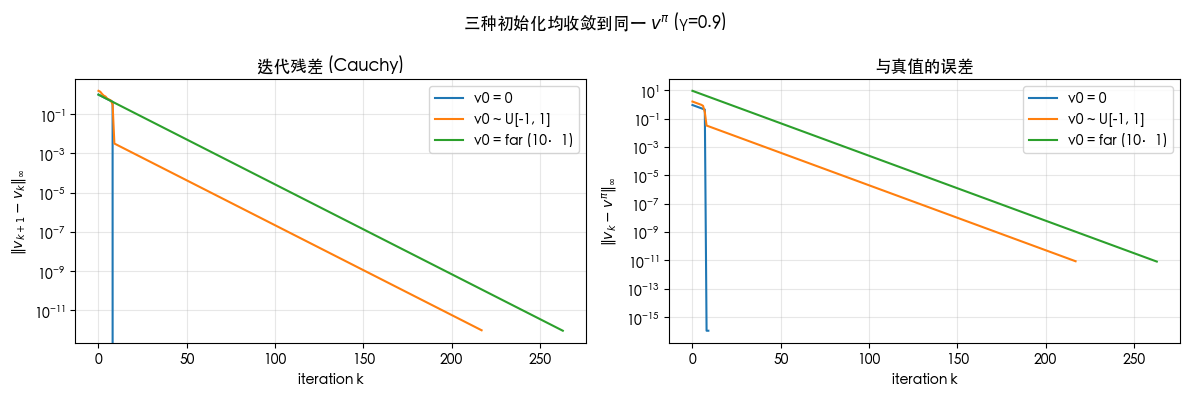

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, (v, res, err) in results.items():
    axes[0].semilogy(res, label=name)
    axes[1].semilogy(err, label=name)
axes[0].set_xlabel('iteration k'); axes[0].set_ylabel(r'$\|v_{k+1}-v_k\|_\infty$')
axes[0].set_title('迭代残差 (Cauchy)')
axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].set_xlabel('iteration k'); axes[1].set_ylabel(r'$\|v_k - v^\pi\|_\infty$')
axes[1].set_title('与真值的误差')
axes[1].grid(alpha=0.3); axes[1].legend()
fig.suptitle('三种初始化均收敛到同一 $v^\\pi$ (γ=0.9)')
plt.tight_layout()
plt.savefig('figures/three_inits_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

**观察**：无论初值多远，残差都按 ~γ 倍/轮线性下降（半对数图呈直线，斜率为 $\log\gamma$）—— 这是 γ-收缩的实证。

## 3. γ 影响收敛速度

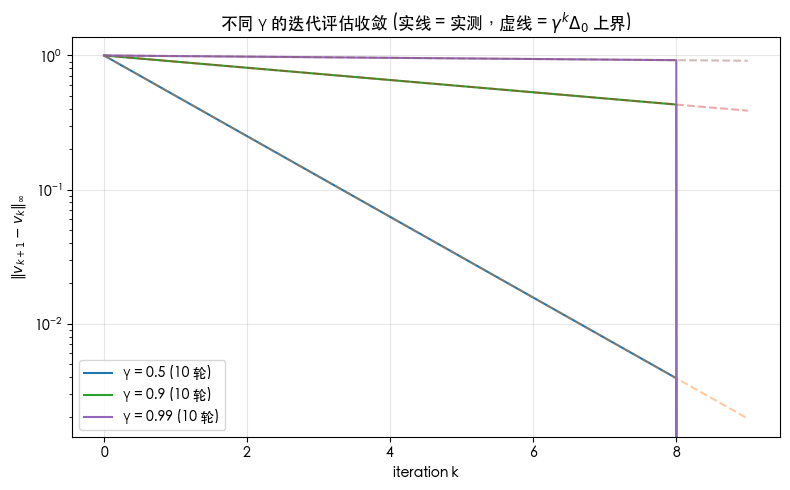

In [5]:
gammas = [0.5, 0.9, 0.99]
fig, ax = plt.subplots(figsize=(8, 5))
for gamma in gammas:
    # 重新求 v_true 因 γ 改变了 MDP 的 v
    env_g = GridWorld(GridConfig(gamma=gamma))
    _, pi_g, _ = env_g.value_iteration()
    P_g = env_g.transition_matrix(pi_g); r_g = env_g.reward_vector(pi_g)
    v_true_g = env_g.solve_bellman(pi_g)
    _, res, _ = iterative_evaluation(P_g, r_g, gamma, np.zeros(n), v_true=v_true_g, tol=1e-12, max_iter=3000)
    ax.semilogy(res, label=f'γ = {gamma} ({len(res)} 轮)')
    # 理论上界：γ^k * Δ_0
    bound = [res[0] * gamma**k for k in range(len(res))]
    ax.semilogy(bound, '--', alpha=0.4)
ax.set_xlabel('iteration k')
ax.set_ylabel(r'$\|v_{k+1}-v_k\|_\infty$')
ax.set_title('不同 γ 的迭代评估收敛 (实线 = 实测，虚线 = $\\gamma^k\\Delta_0$ 上界)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('figures/gamma_convergence_speed.png', dpi=120, bbox_inches='tight')
plt.show()

**观察**：γ 越接近 1，收敛越慢。γ=0.99 时迭代次数比 γ=0.5 多两个数量级。

## 4. 课堂诊断小结

| 论断 | 数值 |
|---|---|
| 任意初值都收敛 | 三种 v₀ 最终残差 < 1e-12 |
| 收敛速率 ≈ γ | 半对数图斜率 = log γ |
| γ → 1 时迭代轮数 ↑ | γ=0.5: ~30 轮; γ=0.99: ~2000 轮 |

## 思考题

1. 用一个差到爆的初值（v₀=10⁶·1）会改变收敛速率吗？还是只改变"前期残差"？
2. 把 γ 设到 1.0 后，迭代还会收敛吗？什么条件下会？（提示：终止状态 / 非吸收 chain）
3. L4 价值迭代里的 $T$（最优算子，含 $\max$）也是 γ-收缩。本 notebook 的 $T_\pi$（线性，不含 max）是它的特例吗？